# IP-Adapter Spike — SDXL + Folk-Art Reference Conditioning

**Question this experiment answers:** Does IP-Adapter, on vanilla pretrained SDXL with no LoRA training, inject Tanjore / Kalighat / Madhubani aesthetic onto Indian snack packaging outputs?

**Grid:** 3 prompts × 3 traditions × 3 IP-Adapter scales × 2 seeds = 54 images  
**+ Baselines:** 3 prompts × 2 seeds = 6 (scale=0.0; reference ignored)  
**Total:** 60 images at 768×768  
**Expected runtime on RTX 3060 Laptop (6 GB):** 90–120 minutes

**Outputs go to:** `outputs/spike/ip_adapter/` with sibling JSON configs per image, plus a grid visualisation.

## Cell 1 — Setup and configuration

In [1]:
import os, json, time
from pathlib import Path

# Memory allocator tweak — helps prevent fragmentation OOM on small VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512,expandable_segments:True"

import torch
from diffusers import AutoPipelineForText2Image
from diffusers.utils import load_image
from PIL import Image
import matplotlib.pyplot as plt

# ----- configuration -----
MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"
RESOLUTION = 768                  # 768 fits comfortably; bump to 1024 if you have headroom
STEPS = 25
GUIDANCE = 7.5

PROMPTS = {
    "p1": "Front-facing product photograph of an Indian snack packet, professional product photography, white background, sharp focus",
    "p2": "Product packaging design for an Indian potato chips packet, vibrant, professional photo, isolated on white",
    "p3": "Indian savoury snack package, commercial product shot, studio lighting, clean composition",
}
NEGATIVE = "blurry, low quality, watermark, distorted, deformed, jpeg artifacts, multiple products"

# Reference images — LOCKED from our selection process. Update paths if filenames differ.
REFERENCES = {
    "madhubani": "data/processed/style_references/bihar/Craft-2-from-Sunaina-Thakur.png",
    "tanjore":   "data/processed/style_references/tamil_nadu/Navaneeta_Krishna_-_Google_Art_Project.png",
    "kalighat":  "data/processed/style_references/west_bengal/A_Bengali_Lady_Krishna_Killing_the_Demon_Bakasura_6125147052.png",
}

IP_SCALES = [0.4, 0.6, 0.8]
SEEDS = [42, 1337]

OUT_DIR = Path("../outputs/spike/ip_adapter")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ----- sanity check references exist -----
print("Checking reference images...")
for name, path in REFERENCES.items():
    p = Path(path)
    if not p.exists():
        # try with current dir as project root
        alt = Path("..") / p
        if alt.exists():
            REFERENCES[name] = str(alt)
            print(f"  {name}: FOUND at {alt}")
        else:
            raise FileNotFoundError(f"Reference for '{name}' not found at {p} or {alt}")
    else:
        print(f"  {name}: FOUND at {p}")

print(f"\nGPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Output dir: {OUT_DIR.resolve()}")

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


Checking reference images...
  madhubani: FOUND at ..\data\processed\style_references\bihar\Craft-2-from-Sunaina-Thakur.png
  tanjore: FOUND at ..\data\processed\style_references\tamil_nadu\Navaneeta_Krishna_-_Google_Art_Project.png
  kalighat: FOUND at ..\data\processed\style_references\west_bengal\A_Bengali_Lady_Krishna_Killing_the_Demon_Bakasura_6125147052.png

GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.4 GB
Output dir: C:\Users\Vivek\Documents\dissertation\outputs\spike\ip_adapter


## Cell 2 — Load SDXL + IP-Adapter

First run downloads the IP-Adapter weights (~700 MB). SDXL should already be in your HuggingFace cache from the earlier spike. Total load time: 30–90 seconds depending on cache state.

In [2]:
print("Loading SDXL...")
t0 = time.time()

pipe = AutoPipelineForText2Image.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
)

pipe.enable_model_cpu_offload()
pipe.enable_vae_slicing()
pipe.enable_vae_tiling()

print(f"  SDXL loaded in {time.time()-t0:.1f}s")

print("\nLoading IP-Adapter...")
t0 = time.time()
pipe.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter_sdxl.bin",
)
print(f"  IP-Adapter loaded in {time.time()-t0:.1f}s")

# Push the image encoder to GPU — cpu_offload doesn't catch it
if hasattr(pipe, "image_encoder") and pipe.image_encoder is not None:
    pipe.image_encoder.to("cuda")
    print(f"  Image encoder on: {pipe.image_encoder.device}")

print("\nPipeline ready.")

Loading SDXL...


C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

...

  SDXL loaded in 2.4s

Loading IP-Adapter...


Loading weights:   0%|          | 0/776 [00:00<?, ?it/s]

  IP-Adapter loaded in 1.9s


C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


  Image encoder on: cuda:0

Pipeline ready.


## Cell 3 — Quick smoke test (one IP-Adapter generation)

Before launching the full 60-image grid, generate ONE conditioned image to confirm everything works. ~90 seconds.

  0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Smoke test generated in 809.7s


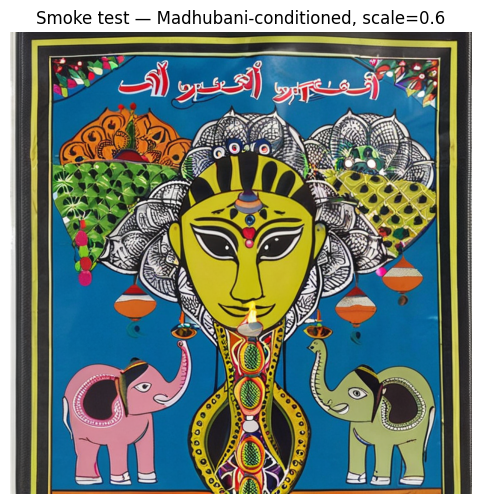

In [5]:
test_ref = load_image(REFERENCES["madhubani"])
pipe.set_ip_adapter_scale(0.6)

g = torch.Generator(device="cuda").manual_seed(42)
t0 = time.time()
img = pipe(
    prompt=PROMPTS["p1"],
    negative_prompt=NEGATIVE,
    ip_adapter_image=test_ref,
    width=RESOLUTION, height=RESOLUTION,
    num_inference_steps=STEPS,
    guidance_scale=GUIDANCE,
    generator=g,
).images[0]
print(f"Smoke test generated in {time.time()-t0:.1f}s")

plt.figure(figsize=(6, 6))
plt.imshow(img); plt.axis("off"); plt.title("Smoke test — Madhubani-conditioned, scale=0.6")
plt.show()

## Cell 4 — Full spike grid (the long run)

Resumes from where it left off if interrupted. Walk away for ~90 minutes.

In [ ]:
def generate(prompt, seed, scale, ref_path, out_path):
    """One generation, with config JSON saved alongside."""
    if out_path.exists():
        return False  # already done
    
    if scale == 0.0:
        # Baseline: no reference, IP-Adapter effectively off
        pipe.set_ip_adapter_scale(0.0)
        # We still need to pass an image to keep the pipeline happy; will be ignored at scale=0
        ref = load_image(REFERENCES["madhubani"])
    else:
        pipe.set_ip_adapter_scale(scale)
        ref = load_image(ref_path)
    
    g = torch.Generator(device="cuda").manual_seed(seed)
    t0 = time.time()
    img = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE,
        ip_adapter_image=ref,
        width=RESOLUTION, height=RESOLUTION,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=g,
    ).images[0]
    elapsed = time.time() - t0
    
    img.save(out_path, "PNG")
    # save config beside it
    config = {
        "prompt": prompt,
        "negative_prompt": NEGATIVE,
        "seed": seed,
        "ip_adapter_scale": scale,
        "reference": str(ref_path) if scale > 0 else "",
        "width": RESOLUTION, "height": RESOLUTION,
        "steps": STEPS, "guidance": GUIDANCE,
        "model": MODEL_ID,
        "ip_adapter": "h94/IP-Adapter sdxl_models/ip-adapter_sdxl.bin",
        "elapsed_s": round(elapsed, 1),
    }
    out_path.with_suffix(".json").write_text(json.dumps(config, indent=2))
    return True


# Build the full task list first
tasks = []

# Baselines (scale=0.0): one per prompt × seed, no reference
for pk, prompt in PROMPTS.items():
    for seed in SEEDS:
        out = OUT_DIR / f"baseline_{pk}_s{seed}.png"
        tasks.append({"prompt": prompt, "seed": seed, "scale": 0.0,
                      "ref": "", "out": out, "tag": f"baseline {pk} s{seed}"})

# Reference-conditioned generations
for tradition, ref_path in REFERENCES.items():
    for pk, prompt in PROMPTS.items():
        for seed in SEEDS:
            for scale in IP_SCALES:
                scale_tag = f"{scale:.1f}".replace(".", "")
                out = OUT_DIR / f"{tradition}_{pk}_s{seed}_scale{scale_tag}.png"
                tasks.append({"prompt": prompt, "seed": seed, "scale": scale,
                              "ref": ref_path, "out": out,
                              "tag": f"{tradition} {pk} s{seed} scale={scale}"})

print(f"Total tasks: {len(tasks)}")
already_done = sum(1 for t in tasks if t["out"].exists())
print(f"Already generated (will skip): {already_done}")
print(f"To do: {len(tasks) - already_done}")
print()

# Run them
grand_start = time.time()
for i, t in enumerate(tasks, 1):
    if t["out"].exists():
        print(f"[{i:>3}/{len(tasks)}] SKIP {t['tag']}")
        continue
    print(f"[{i:>3}/{len(tasks)}] {t['tag']} ...", end=" ", flush=True)
    t0 = time.time()
    generate(t["prompt"], t["seed"], t["scale"], t["ref"], t["out"])
    print(f"{time.time()-t0:.1f}s")

total = time.time() - grand_start
print(f"\nGrand total: {total/60:.1f} min for {len(tasks) - already_done} new images.")
print(f"Outputs: {OUT_DIR.resolve()}")

## Cell 5 — Build contact-sheet grid for visual review

Assembles all outputs into one big PNG so you can scroll through and apply the rubric.

In [ ]:
def build_grid(traditions, prompts, scales, seeds, thumb=256):
    """One row per (tradition, scale, seed); columns are prompts. Baselines in their own block above."""
    rows = []
    labels = []
    
    # baseline block
    for seed in seeds:
        row = []
        for pk in prompts:
            p = OUT_DIR / f"baseline_{pk}_s{seed}.png"
            row.append(Image.open(p).resize((thumb, thumb)) if p.exists() else None)
        rows.append(row)
        labels.append(f"BASELINE s{seed}")
    
    # reference blocks
    for tradition in traditions:
        for scale in scales:
            scale_tag = f"{scale:.1f}".replace(".", "")
            for seed in seeds:
                row = []
                for pk in prompts:
                    p = OUT_DIR / f"{tradition}_{pk}_s{seed}_scale{scale_tag}.png"
                    row.append(Image.open(p).resize((thumb, thumb)) if p.exists() else None)
                rows.append(row)
                labels.append(f"{tradition} s{seed} sc={scale}")
    
    cols = len(prompts)
    n_rows = len(rows)
    label_w = 180
    canvas = Image.new("RGB", (label_w + cols * thumb, n_rows * thumb), "white")
    
    from PIL import ImageDraw, ImageFont
    draw = ImageDraw.Draw(canvas)
    try:
        font = ImageFont.truetype("arial.ttf", 14)
    except Exception:
        font = ImageFont.load_default()
    
    for i, (row, lab) in enumerate(zip(rows, labels)):
        draw.text((6, i * thumb + thumb // 2 - 8), lab, fill="black", font=font)
        for j, im in enumerate(row):
            if im is not None:
                canvas.paste(im, (label_w + j * thumb, i * thumb))
    
    return canvas

grid = build_grid(
    traditions=list(REFERENCES.keys()),
    prompts=list(PROMPTS.keys()),
    scales=IP_SCALES,
    seeds=SEEDS,
    thumb=256,
)
grid_path = OUT_DIR.parent / "ip_adapter_grid.png"
grid.save(grid_path)
print(f"Grid saved: {grid_path.resolve()}  ({grid.size[0]}×{grid.size[1]} px)")
plt.figure(figsize=(14, n if (n := len(REFERENCES) * len(IP_SCALES) * len(SEEDS) + len(SEEDS)) else 12))
plt.imshow(grid); plt.axis("off"); plt.show()

## Cell 6 — Create failure-log CSV scaffold for rubric scoring

One row per generated image, with empty rubric-axis columns. You'll fill these in across two sessions ≥48h apart as per the pre-committed rubric methodology.

In [ ]:
import pandas as pd
from datetime import datetime

rows = []
for p in sorted(OUT_DIR.glob("*.png")):
    name = p.stem
    if name.startswith("baseline_"):
        tradition, scale_str = "baseline", "0.0"
    else:
        parts = name.split("_")
        tradition = parts[0]
        scale_str = parts[-1].replace("scale", "")
        scale_str = f"{scale_str[0]}.{scale_str[1:]}" if len(scale_str) > 1 else scale_str
    
    rows.append({
        "filename": p.name,
        "tradition": tradition,
        "ip_scale": scale_str,
        # Rubric axes — 0–3 per the pre-committed rubric
        "session1_text_legibility": "",
        "session1_regional_appropriateness": "",
        "session1_packaging_plausibility": "",
        "session1_visual_quality": "",
        "session1_date": "",
        "session2_text_legibility": "",
        "session2_regional_appropriateness": "",
        "session2_packaging_plausibility": "",
        "session2_visual_quality": "",
        "session2_date": "",
        "failure_mode": "",
        "notes": "",
    })

df = pd.DataFrame(rows)
log_path = Path("../evaluation/spike_ip_adapter_scores.csv")
log_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(log_path, index=False)
print(f"Failure log scaffold: {log_path.resolve()}")
print(f"Rows: {len(df)}")
print()
print("Rubric reminder (from rubric.md):")
print("  0 = absent/wrong, 1 = weak, 2 = present-but-imperfect, 3 = strong")
print("  Two sessions, ≥48h apart, anonymised filenames at scoring time.")